In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import json
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

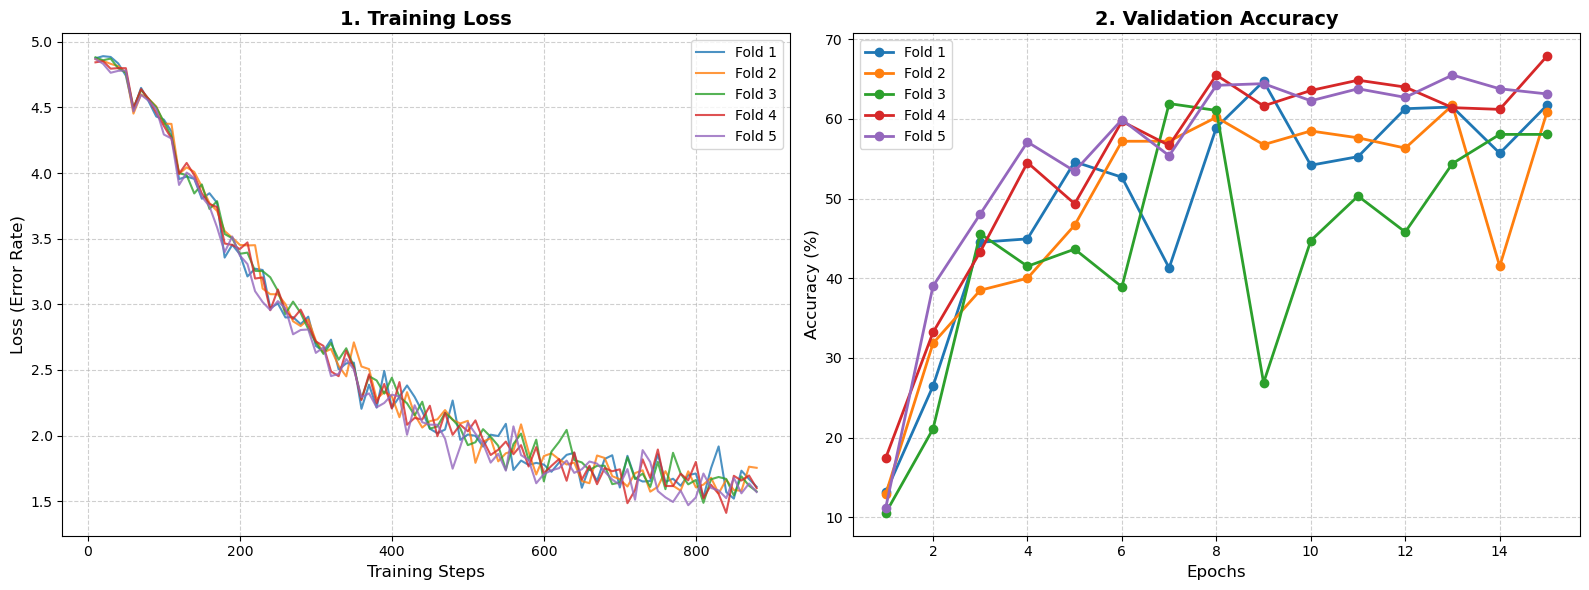

In [ ]:
# 224x224 model 
plt.figure(figsize=(16, 6))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

folds = 5
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i in range(1, folds + 1):
    fold_dir = f"./garbage_model_fold_{i}"

    if not os.path.exists(fold_dir):
        print(f"Could not find folder: {fold_dir}")
        continue

    # logs inside 'checkpoint-XXX' folders
    checkpoints = [d for d in os.listdir(fold_dir) if d.startswith("checkpoint")]
    if not checkpoints:
        print(f"No checkpoints found in {fold_dir}")
        continue

    checkpoints.sort(key=lambda x: int(x.split("-")[1]))
    latest_checkpoint = checkpoints[-1]

    state_path = os.path.join(fold_dir, latest_checkpoint, "trainer_state.json")

    if os.path.exists(state_path):
        with open(state_path, "r") as f:
            state = json.load(f)

        log_history = state["log_history"]

        # Loss for every 10 steps (logging_steps=10)
        train_steps = [log["step"] for log in log_history if "loss" in log]
        train_loss = [log["loss"] for log in log_history if "loss" in log]

        # Accuracy per each epoch
        eval_epochs = [log["epoch"] for log in log_history if "eval_accuracy" in log]
        eval_acc = [log["eval_accuracy"] * 100 for log in log_history if "eval_accuracy" in log] 

        ax1.plot(train_steps, train_loss, color=colors[i-1], alpha=0.8, label=f"Fold {i}")
        ax2.plot(eval_epochs, eval_acc, color=colors[i-1], marker='o', linewidth=2, label=f"Fold {i}")

# Training Loss
ax1.set_title("1. Training Loss", fontsize=14, fontweight='bold')
ax1.set_xlabel("Training Steps", fontsize=12)
ax1.set_ylabel("Loss (Error Rate)", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Validation Accuracy 
ax2.set_title("2. Validation Accuracy", fontsize=14, fontweight='bold')
ax2.set_xlabel("Epochs", fontsize=12)
ax2.set_ylabel("Accuracy (%)", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

Learning rates for all 5 folds are quite smooth. It proves that our 5e-5 learning rate and our warmup_ratio=0.1 were the good settings for fine-tuning the EfficientNet. Taking into consideration convergence, by the end of the steps (around the 500 mark), the lines flatten out near the bottom. This means the model has squeezed almost all the useful information it can out of the training data.

Looking at the Validation Accuracy chart, all five folds start low (around 20-40%) and climb steadily together up to the 60-70% range. Average Accuracy across all 5 folds is 64.36% and standard deviation around 2.31%. The number of epochs between 10 and 15 was alos a good choice. The lines for the different folds plateau arond the 10th epoch and mostly keep this level of accuracy till epoch 15. 

Based on the graphs, we can conclude that 224x224 model is robust and learning consistently across every possible slice of the dataset. 

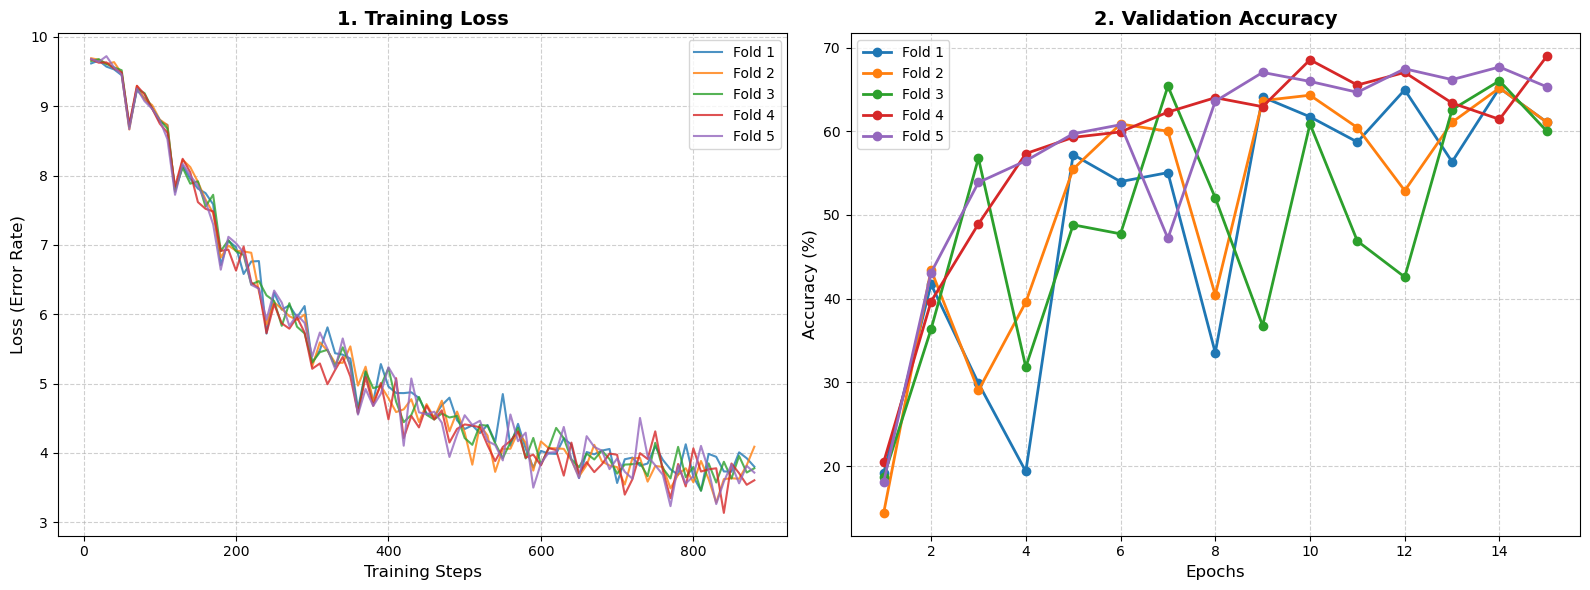

In [3]:
# 448x448 model
plt.figure(figsize=(16, 6))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

folds = 5
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i in range(1, folds + 1):
    fold_dir = f"./garbage_model_448_fold_{i}"

    if not os.path.exists(fold_dir):
        print(f"Could not find folder: {fold_dir}")
        continue

    # logs inside 'checkpoint-XXX' folders
    checkpoints = [d for d in os.listdir(fold_dir) if d.startswith("checkpoint")]
    if not checkpoints:
        print(f"No checkpoints found in {fold_dir}")
        continue

    checkpoints.sort(key=lambda x: int(x.split("-")[1]))
    latest_checkpoint = checkpoints[-1]

    state_path = os.path.join(fold_dir, latest_checkpoint, "trainer_state.json")

    if os.path.exists(state_path):
        with open(state_path, "r") as f:
            state = json.load(f)

        log_history = state["log_history"]

        # Loss for every 10 steps (logging_steps=10)
        train_steps = [log["step"] for log in log_history if "loss" in log]
        train_loss = [log["loss"] for log in log_history if "loss" in log]

        # Accuracy per each epoch
        eval_epochs = [log["epoch"] for log in log_history if "eval_accuracy" in log]
        eval_acc = [log["eval_accuracy"] * 100 for log in log_history if "eval_accuracy" in log] 

        ax1.plot(train_steps, train_loss, color=colors[i-1], alpha=0.8, label=f"Fold {i}")
        ax2.plot(eval_epochs, eval_acc, color=colors[i-1], marker='o', linewidth=2, label=f"Fold {i}")

# Training Loss
ax1.set_title("1. Training Loss", fontsize=14, fontweight='bold')
ax1.set_xlabel("Training Steps", fontsize=12)
ax1.set_ylabel("Loss (Error Rate)", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Validation Accuracy 
ax2.set_title("2. Validation Accuracy", fontsize=14, fontweight='bold')
ax2.set_xlabel("Epochs", fontsize=12)
ax2.set_ylabel("Accuracy (%)", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

Now lets analyze the training process for the model with increased resolution to 448x448. The same as 224x224 model, the training loss drops fast and smooth, approaching near-zero very quickly. This tells us the model had no problem memorizing the training data. The higher resolution gave it so much detail that it easily found unique features for every single image.

However, we can notice a claer difference for the accuracy scores acros the folds and epochs. Average Accuracy across all 5 folds is 66.60% and standard deviation around 1.50%. Notice how the accuracy peaks early (around epochs 2-4) mostly for the folds 1,2 and 3, hitting roughly 60-70%. But then, as training continues, the accuracy drops and becomes unstable. This could happen because the model was given so much fine detail, it started memorizing noise and specific quirks of the training images (like the exact background of a specific bottle) rather than learning the general shapes of the garbage. When it was tested on the validation set, those hyper-specific details weren't there, so its guesses became worse. If we Look at the wide spread between the lines compared to the tight grouping of your 224x224 model, fold 3 (green) crashes down to below 65%, while Fold 4 (red) stays near 70%. This instability is a major warning sign that the model is no longer generalizing well.

From our experiment we can see that simply increasing the image resolution from 224x224 to 448x448 decreased the overall stability and generalization of the model, leading to overfitting. The 224x224 model, while lower resolution, was forced to learn general shapes and edges because it couldn't rely on tiny details, making it much more robust when looking at new, unseen garbage.

Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

Model loaded

Found 6 real-world images. Starting classification...

test1.jpg:
Model says: HARD PLASTIC (45.84% confident)

test2.jpg:
Model says: PAPER TOWEL (31.28% confident)

test3.jpg:
Model says: SOFT PLASTICS (50.68% confident)

test4.jpg:
Model says: GLASS (39.88% confident)

test5.jpg:
Model says: GLASS (29.76% confident)

test6.jpg:
Model says: SOFT PLASTICS (62.51% confident)



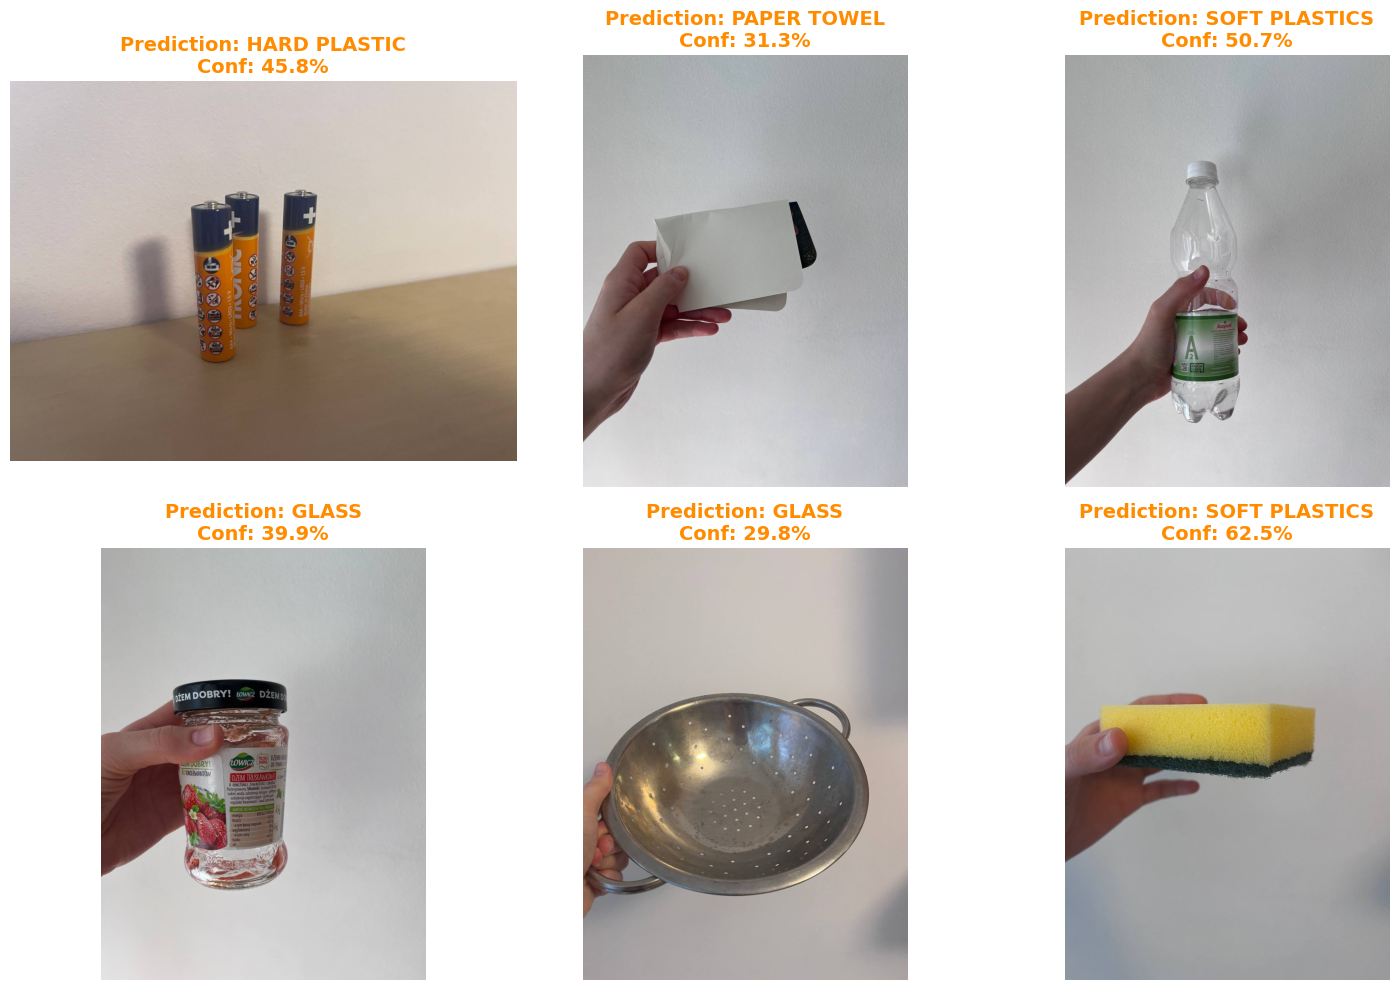

In [4]:
model_path_224 = "./best_garbage_classifier"
test_folder = "./real_images_test"

processor = AutoImageProcessor.from_pretrained(model_path_224)
model = AutoModelForImageClassification.from_pretrained(model_path_224)
print("Model loaded\n")

if not os.path.exists(test_folder):
    print(f"Error: Could not find the folder '{test_folder}'")
    exit()

valid_extensions = (".jpg", ".jpeg", ".png", ".webp")
image_files = [f for f in os.listdir(test_folder) if f.lower().endswith(valid_extensions)]

if len(image_files) == 0:
    print(f"Error: Found the folder '{test_folder}', but there are no images inside it")
    exit()

print(f"Found {len(image_files)} real-world images. Starting classification...\n")


num_images = len(image_files)
cols = 3 # Display 3 images per row
rows = (num_images + cols - 1) // cols 
plt.figure(figsize=(15, 5 * rows))


for i, filename in enumerate(image_files):
    image_path = os.path.join(test_folder, filename)
    
    raw_image = Image.open(image_path).convert("RGB")
    inputs = processor(raw_image, return_tensors="pt") # Transform it into the exact mathematical format the model expects
    
    with torch.no_grad(): # no_grad makes the model fast
        outputs = model(**inputs)

    probabilities = F.softmax(outputs.logits, dim=1)[0]
    
    best_prediction_id = torch.argmax(probabilities).item()
    confidence = probabilities[best_prediction_id].item() * 100
    predicted_label = model.config.id2label[best_prediction_id]

    print(f"{filename}:")
    print(f"Model says: {predicted_label.upper()} ({confidence:.2f}% confident)\n")
    
    plt.subplot(rows, cols, i + 1)
    plt.imshow(raw_image)
    plt.axis('off')
    
    title_color = "green" if confidence > 70 else "darkorange"
    plt.title(f"Prediction: {predicted_label.upper()}\nConf: {confidence:.1f}%", 
              fontsize=14, fontweight='bold', color=title_color)

plt.tight_layout()
plt.show()

Not that bad :)

Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

Model loaded

Found 6 real-world images. Starting classification...

test1.jpg:
Model says: SOFT PLASTICS (22.41% confident)

test2.jpg:
Model says: PAPER (20.65% confident)

test3.jpg:
Model says: GLASS (46.98% confident)

test4.jpg:
Model says: PAPER TOWEL (33.42% confident)

test5.jpg:
Model says: ALUMINIUM (34.74% confident)

test6.jpg:
Model says: SOFT PLASTICS (62.55% confident)



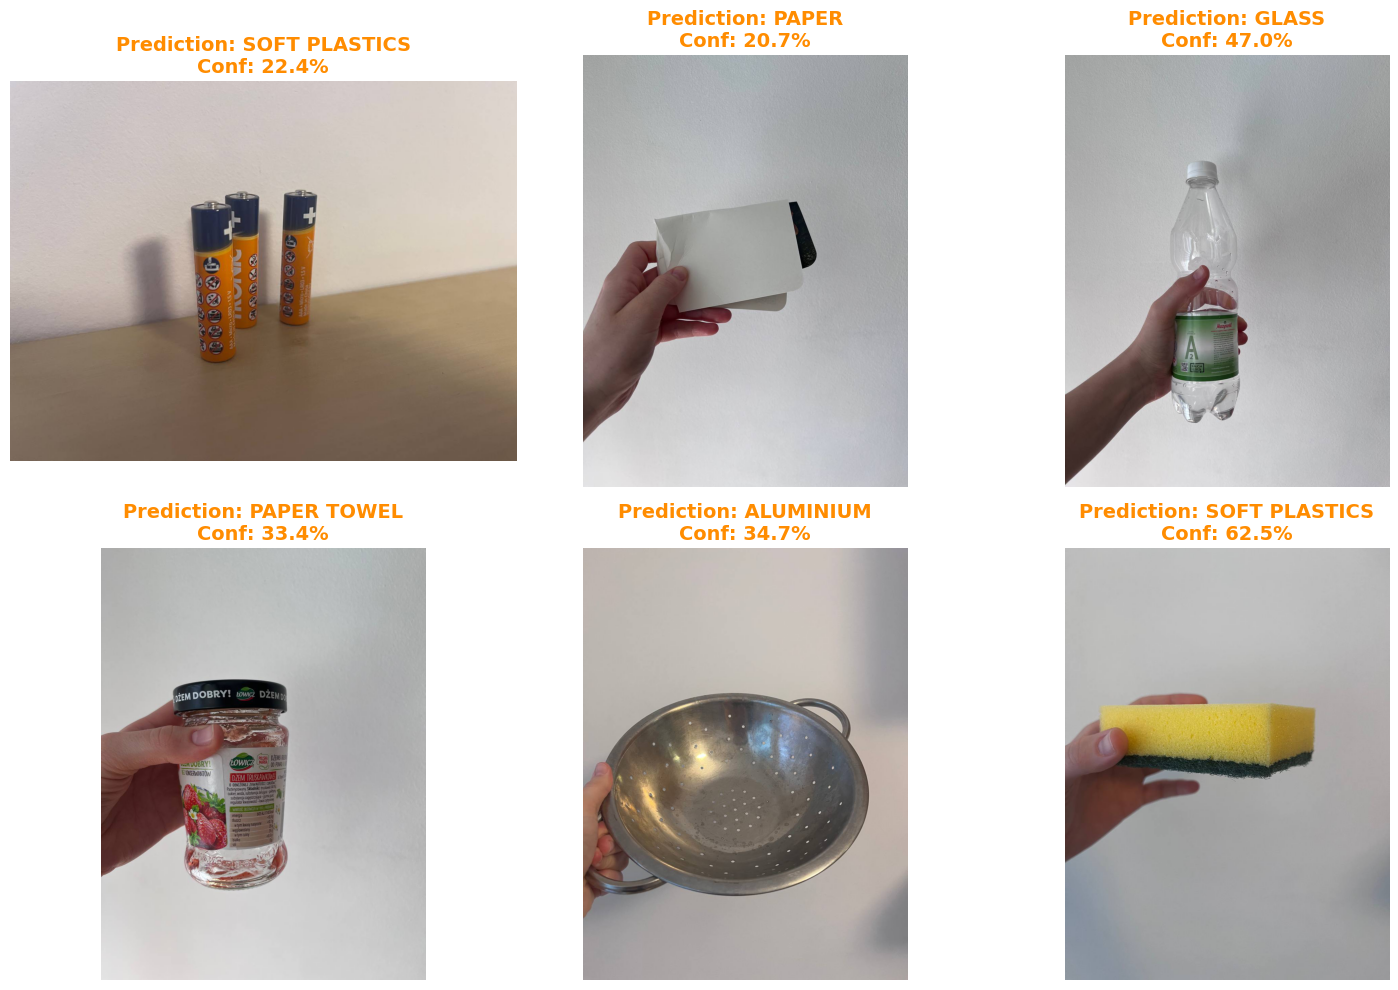

In [5]:
model_path_448 = "./model_448px_experiment"
test_folder = "./real_images_test"

processor = AutoImageProcessor.from_pretrained(model_path_448)
model = AutoModelForImageClassification.from_pretrained(model_path_448)
print("Model loaded\n")

if not os.path.exists(test_folder):
    print(f"Error: Could not find the folder '{test_folder}'")
    exit()

valid_extensions = (".jpg", ".jpeg", ".png", ".webp")
image_files = [f for f in os.listdir(test_folder) if f.lower().endswith(valid_extensions)]

if len(image_files) == 0:
    print(f"Error: Found the folder '{test_folder}', but there are no images inside it")
    exit()

print(f"Found {len(image_files)} real-world images. Starting classification...\n")


num_images = len(image_files)
cols = 3 # Display 3 images per row
rows = (num_images + cols - 1) // cols 
plt.figure(figsize=(15, 5 * rows))


for i, filename in enumerate(image_files):
    image_path = os.path.join(test_folder, filename)
    
    raw_image = Image.open(image_path).convert("RGB")
    inputs = processor(raw_image, return_tensors="pt") # Transform it into the exact mathematical format the model expects
    
    with torch.no_grad(): # no_grad makes the model fast
        outputs = model(**inputs)

    probabilities = F.softmax(outputs.logits, dim=1)[0]
    
    best_prediction_id = torch.argmax(probabilities).item()
    confidence = probabilities[best_prediction_id].item() * 100
    predicted_label = model.config.id2label[best_prediction_id]

    print(f"{filename}:")
    print(f"Model says: {predicted_label.upper()} ({confidence:.2f}% confident)\n")
    
    plt.subplot(rows, cols, i + 1)
    plt.imshow(raw_image)
    plt.axis('off')
    
    title_color = "green" if confidence > 70 else "darkorange"
    plt.title(f"Prediction: {predicted_label.upper()}\nConf: {confidence:.1f}%", 
              fontsize=14, fontweight='bold', color=title_color)

plt.tight_layout()
plt.show()

Results are not sufficient... :(

Taking into cosideration resuls of the two models (for 224 and 448 pixels resolution), the best and more sufficient result for the 224px model. 